# Confirmatory H1 Sweep: Verdict

**Question.** Did the long-lived `H1` signal survive a held-out,
pre-registered comparison against matched controls, or was it likely
produced by hand-picked preprocessing hyperparameters?

**Short answer.** The primary confirmatory test rules out a robust
signal. The PCA8/Rips candidate fails decisively. The S15/witness
candidate has dataset-specific positives, but fails the pre-registered
robustness criteria.

This notebook is a report. It loads frozen artifacts and does not
recompute encodings or persistent homology.

In [1]:
from __future__ import annotations

import json
import math
import os
import platform
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

In [2]:
ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent

DEFAULT_OUT_DIR = ROOT / "outputs" / "confirmatory_h1_v1"
PRIMARY_COMPLETE_OUT_DIR = ROOT / "outputs" / "confirmatory_h1_v1_partial_modal"
OUT_DIR = Path(
    os.environ.get(
        "CONFIRMATORY_H1_OUT",
        PRIMARY_COMPLETE_OUT_DIR if PRIMARY_COMPLETE_OUT_DIR.exists() else DEFAULT_OUT_DIR,
    )
)

REQUIRED_FILES = {
    "manifest": OUT_DIR / "manifest.json",
    "conditions": OUT_DIR / "conditions.csv",
    "runs": OUT_DIR / "runs.csv",
    "paired_primary": OUT_DIR / "paired_primary.csv",
    "verdict": OUT_DIR / "verdict.json",
    "pipeline_summary": OUT_DIR / "pipeline_summary.csv",
    "dataset_summary": OUT_DIR / "dataset_summary.csv",
    "stability_summary": OUT_DIR / "stability_summary.csv",
}
OPTIONAL_FILES = {
    "failed_runs": OUT_DIR / "failed_runs.csv",
    "diagrams": OUT_DIR / "diagrams.csv",
    "barcodes": OUT_DIR / "barcodes.csv",
    "betti_curves": OUT_DIR / "betti_curves.csv",
    "patch_map_summary": OUT_DIR / "patch_map_summary.csv",
}

load_errors: dict[str, str] = {}


def read_json_artifact(name: str, path: Path) -> dict:
    if not path.exists() or path.stat().st_size == 0:
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        load_errors[name] = repr(exc)
        return {}


def read_csv_artifact(name: str, path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()
    except Exception as exc:
        load_errors[name] = repr(exc)
        return pd.DataFrame()


def display_path(path: Path) -> str:
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)


def note(title: str, body: str, level: str = "info") -> None:
    prefix = {"info": "Note", "warn": "Warning", "ok": "OK"}.get(level, "Note")
    text = textwrap.dedent(body).strip()
    quoted = "\n".join(f"> {line}" if line else ">" for line in text.splitlines())
    display(Markdown(f"> **{prefix}: {title}**\n>\n{quoted}"))


def numeric(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    out = frame.copy()
    for column in columns:
        if column in out.columns:
            out[column] = pd.to_numeric(out[column], errors="coerce")
    return out


def h1_only(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty or "dim" not in frame.columns:
        return frame.copy()
    dim = pd.to_numeric(frame["dim"], errors="coerce")
    out = frame[dim.eq(1)].copy()
    return out if not out.empty else frame.copy()


def bootstrap_ci(values: pd.Series, n_boot: int = 5000, seed: int = 20260501) -> tuple[float, float, float]:
    clean = pd.to_numeric(values, errors="coerce").dropna().to_numpy(dtype=float)
    if len(clean) == 0:
        return math.nan, math.nan, math.nan
    rng = np.random.default_rng(seed)
    means = rng.choice(clean, size=(n_boot, len(clean)), replace=True).mean(axis=1)
    return float(clean.mean()), float(np.quantile(means, 0.025)), float(np.quantile(means, 0.975))


manifest = read_json_artifact("manifest", REQUIRED_FILES["manifest"])
verdict = read_json_artifact("verdict", REQUIRED_FILES["verdict"])
conditions = read_csv_artifact("conditions", REQUIRED_FILES["conditions"])
runs = read_csv_artifact("runs", REQUIRED_FILES["runs"])
paired_primary = read_csv_artifact("paired_primary", REQUIRED_FILES["paired_primary"])
pipeline_summary = read_csv_artifact("pipeline_summary", REQUIRED_FILES["pipeline_summary"])
dataset_summary = read_csv_artifact("dataset_summary", REQUIRED_FILES["dataset_summary"])
stability_summary = read_csv_artifact("stability_summary", REQUIRED_FILES["stability_summary"])
failed_runs = read_csv_artifact("failed_runs", OPTIONAL_FILES["failed_runs"])
patch_map_summary = read_csv_artifact("patch_map_summary", OPTIONAL_FILES["patch_map_summary"])

paired_h1 = numeric(
    h1_only(paired_primary),
    ["observed_norm", "hardest_control_norm", "delta", "ratio", "seed", "dim"],
)
if "win" in paired_h1.columns:
    paired_h1["win"] = paired_h1["win"].astype(str).str.lower().isin(["true", "1", "yes"])

missing_required = [name for name, path in REQUIRED_FILES.items() if not path.exists()]
empty_required = [
    name
    for name, path in REQUIRED_FILES.items()
    if path.exists() and path.is_file() and path.stat().st_size == 0
]
artifacts_ready = not missing_required and not empty_required and not load_errors

if artifacts_ready:
    note("Artifacts loaded", f"Using `{display_path(OUT_DIR)}`.", "ok")
else:
    note(
        "Artifacts incomplete",
        f"""
        Output directory: `{OUT_DIR}`

        Missing required files: `{missing_required or []}`
        Empty required files: `{empty_required or []}`
        Load errors: `{load_errors or {}}`
        """,
        "warn",
    )

> **OK: Artifacts loaded**
>
> Using `outputs/confirmatory_h1_v1_partial_modal`.

## 1. What The Numbers Mean

For every observed run we compute the longest finite `H1` lifetime:

```text
H1 persistence = death - birth
```

For witness complexes the filtration is stored in squared-alpha units,
so the runner first converts lifetimes back to alpha scale:

```text
H1 persistence = sqrt(death) - sqrt(birth)
```

Then we normalize by the run's filtration scale:

```text
h1_norm = max H1 persistence / filtration normalizer
```

Each observed run is matched to four controls processed through the
same pipeline. The comparison is deliberately adversarial:

```text
hardest_control = max(control_h1_norms)
delta = observed_h1_norm - hardest_control
ratio = observed_h1_norm / hardest_control
win = delta > 0
```

A positive `delta` means the observed FLUX tokens beat every matched
control for that dataset, seed, and pipeline setting.

## 2. Pre-Registered Decision Criteria

A primary pipeline was allowed to pass only if **all** criteria held:

```text
mean(delta) >= 0.05
mean(ratio) >= 1.25
bootstrap 95% CI lower bound for mean(delta) > 0
win rate >= 80%
at least 3 / 4 datasets have positive mean(delta)
at least 70% of neighboring stability settings have positive mean(delta)
```

The important hygiene rule: secondary/stability settings can explain a
result, but they cannot rescue a failed primary test.

## 3. Verdict First

### Overall verdict: `ruled_out`

**Hypothesis resolution:** The held-out primary pipelines did not survive controls; the preprocessing-overfit hypothesis is supported.

,pipeline,status,metrics.runs,metrics.mean_delta,metrics.bootstrap_ci_low,metrics.bootstrap_ci_high,metrics.mean_ratio,metrics.win_rate,metrics.positive_datasets,metrics.dataset_count,metrics.stability_positive_rate
0,pca8_sphere_rips,ruled_out,120,-0.2100,-0.2259,-0.1938,0.1997,0.0000,0,4,0.0000
1,s15_witness,ruled_out,120,0.0349,-0.0073,0.0796,2.1889,0.5583,2,4,0.8333


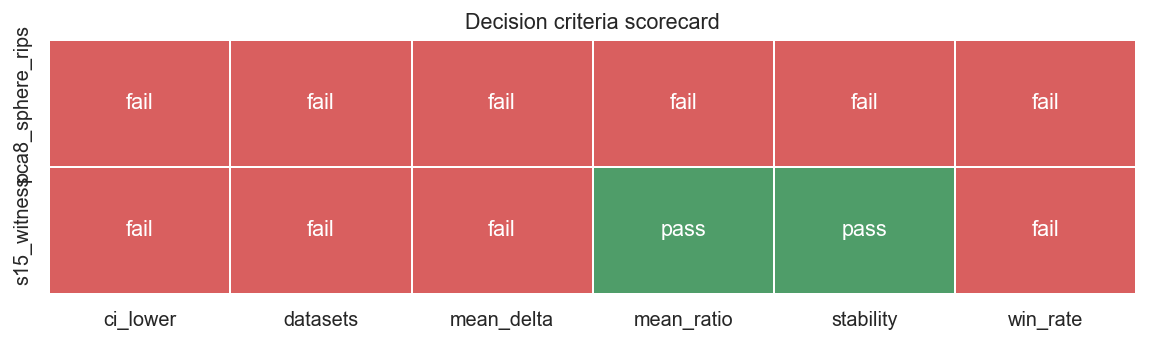

In [3]:
def flatten_dict(d: dict, prefix: str = "") -> dict:
    out: dict[str, object] = {}
    for key, value in d.items():
        name = f"{prefix}.{key}" if prefix else str(key)
        if isinstance(value, dict):
            out.update(flatten_dict(value, name))
        elif isinstance(value, (str, int, float, bool)) or value is None:
            out[name] = value
    return out


decision_rows = []
for pipeline, payload in (verdict.get("pipelines") or {}).items():
    row = {"pipeline": pipeline}
    row.update(flatten_dict(payload))
    decision_rows.append(row)
decision = pd.DataFrame(decision_rows)

if verdict:
    display(
        Markdown(
            "\n".join(
                [
                    f"### Overall verdict: `{verdict.get('verdict', 'not reported')}`",
                    "",
                    f"**Hypothesis resolution:** {verdict.get('hypothesis_resolution', 'not reported')}",
                ]
            )
        )
    )
else:
    note("Verdict unavailable", "`verdict.json` was not loaded.", "warn")

metric_cols = [
    "pipeline",
    "status",
    "metrics.runs",
    "metrics.mean_delta",
    "metrics.bootstrap_ci_low",
    "metrics.bootstrap_ci_high",
    "metrics.mean_ratio",
    "metrics.win_rate",
    "metrics.positive_datasets",
    "metrics.dataset_count",
    "metrics.stability_positive_rate",
]
shown = decision[[c for c in metric_cols if c in decision.columns]].copy() if not decision.empty else pd.DataFrame()
for col in shown.columns:
    if col.startswith("metrics."):
        shown[col] = pd.to_numeric(shown[col], errors="coerce")
display(shown.round(4) if not shown.empty else pd.DataFrame({"message": ["No decision table available."]}))

pass_cols = [c for c in decision.columns if c.startswith("passes.")]
if pass_cols:
    pass_frame = decision.set_index("pipeline")[pass_cols].astype(bool)
    pass_frame.columns = [c.replace("passes.", "") for c in pass_frame.columns]
    fig, ax = plt.subplots(figsize=(9, 2.8))
    sns.heatmap(
        pass_frame.astype(int),
        cmap=sns.color_palette(["#d95f5f", "#4f9d69"], as_cmap=True),
        cbar=False,
        annot=np.where(pass_frame.to_numpy(dtype=bool), "pass", "fail"),
        fmt="",
        linewidths=1,
        linecolor="white",
        ax=ax,
    )
    ax.set_title("Decision criteria scorecard")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## 4. Decisive Evidence

The next three figures are the main readout. They show whether observed
FLUX tokens exceed their hardest matched controls, whether the mean
effect is above zero, and whether the effect is stable across datasets.

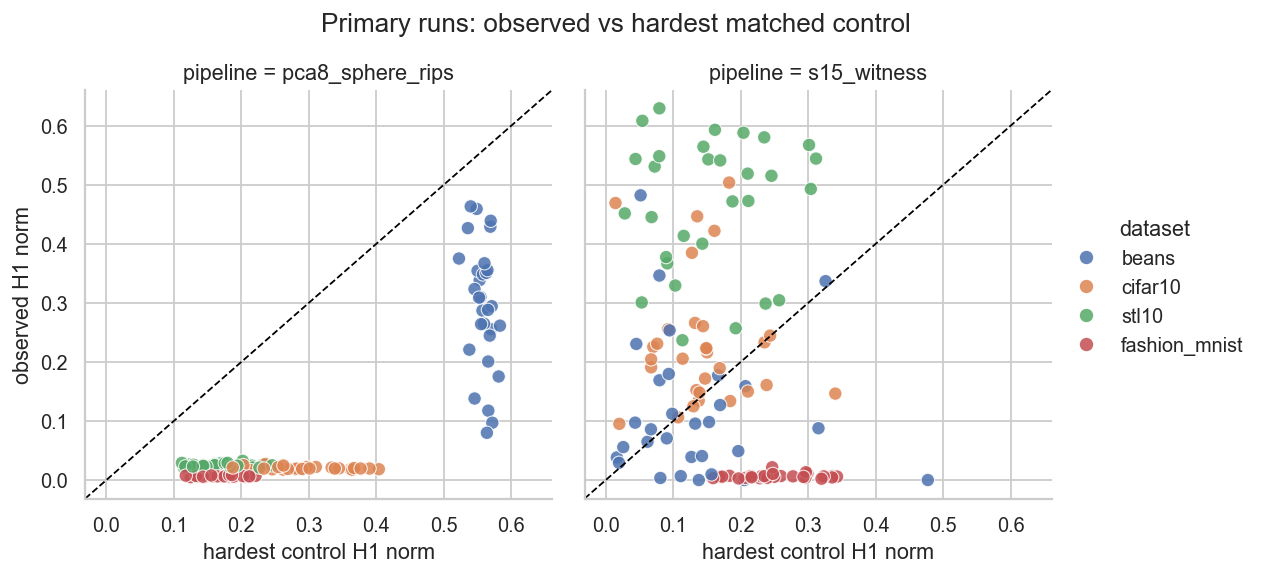

,label,pipeline,mean_delta,ci_low,ci_high,n,kind
0,pca8_sphere_rips / all datasets,pca8_sphere_rips,-0.2100,-0.2260,-0.1943,120,pipeline
2,pca8_sphere_rips / cifar10,pca8_sphere_rips,-0.2656,-0.2885,-0.2446,30,dataset
1,pca8_sphere_rips / beans,pca8_sphere_rips,-0.2636,-0.3024,-0.2242,30,dataset
3,pca8_sphere_rips / fashion_mnist,pca8_sphere_rips,-0.1650,-0.1746,-0.1552,30,dataset
4,pca8_sphere_rips / stl10,pca8_sphere_rips,-0.1457,-0.1587,-0.1329,30,dataset
5,s15_witness / all datasets,s15_witness,0.0349,-0.0073,0.0761,120,pipeline
8,s15_witness / fashion_mnist,s15_witness,-0.2435,-0.2613,-0.2259,30,dataset
6,s15_witness / beans,s15_witness,-0.0176,-0.0745,0.0369,30,dataset
7,s15_witness / cifar10,s15_witness,0.0883,0.0431,0.1374,30,dataset
9,s15_witness / stl10,s15_witness,0.3124,0.2657,0.3588,30,dataset


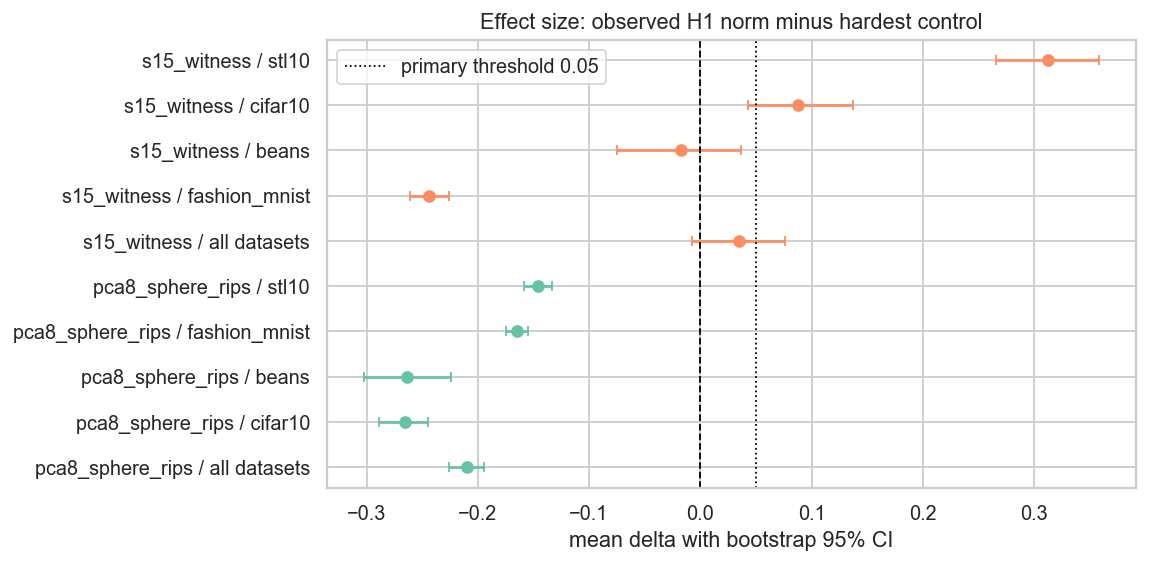

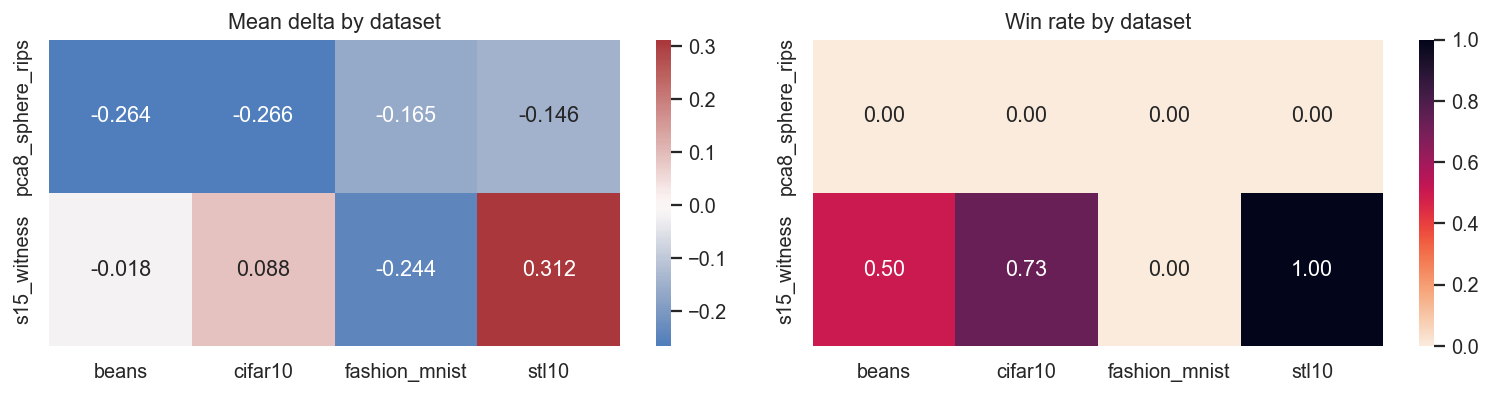

In [4]:
if paired_h1.empty:
    note("Primary evidence unavailable", "`paired_primary.csv` is empty or missing.", "warn")
else:
    required = {"pipeline", "dataset", "observed_norm", "hardest_control_norm", "delta", "win"}
    if required.issubset(paired_h1.columns):
        g = sns.relplot(
            data=paired_h1,
            x="hardest_control_norm",
            y="observed_norm",
            col="pipeline",
            hue="dataset",
            kind="scatter",
            height=4.2,
            aspect=1,
            s=55,
            alpha=0.85,
        )
        for ax in g.axes.flat:
            finite = paired_h1[["observed_norm", "hardest_control_norm"]].replace([np.inf, -np.inf], np.nan).dropna()
            if not finite.empty:
                lo = float(finite.min().min())
                hi = float(finite.max().max())
                pad = max((hi - lo) * 0.05, 0.01)
                ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="black", linestyle="--", linewidth=1)
                ax.set_xlim(lo - pad, hi + pad)
                ax.set_ylim(lo - pad, hi + pad)
            ax.set_xlabel("hardest control H1 norm")
            ax.set_ylabel("observed H1 norm")
        g.fig.suptitle("Primary runs: observed vs hardest matched control", y=1.05)
        plt.show()

        ci_rows = []
        for pipeline, group in paired_h1.groupby("pipeline"):
            mean_delta, lo, hi = bootstrap_ci(group["delta"])
            ci_rows.append({"label": f"{pipeline} / all datasets", "pipeline": pipeline, "mean_delta": mean_delta, "ci_low": lo, "ci_high": hi, "n": len(group), "kind": "pipeline"})
            for dataset, sub in group.groupby("dataset"):
                mean_delta, lo, hi = bootstrap_ci(sub["delta"], n_boot=3000)
                ci_rows.append({"label": f"{pipeline} / {dataset}", "pipeline": pipeline, "mean_delta": mean_delta, "ci_low": lo, "ci_high": hi, "n": len(sub), "kind": "dataset"})
        ci = pd.DataFrame(ci_rows).sort_values(["pipeline", "kind", "mean_delta"], ascending=[True, False, True])
        display(ci.round(4))

        fig, ax = plt.subplots(figsize=(9, max(4.5, 0.36 * len(ci))))
        colors = dict(zip(ci["pipeline"].unique(), sns.color_palette("Set2", n_colors=ci["pipeline"].nunique())))
        y = np.arange(len(ci))
        for i, row in ci.reset_index(drop=True).iterrows():
            ax.errorbar(
                row["mean_delta"],
                i,
                xerr=[[row["mean_delta"] - row["ci_low"]], [row["ci_high"] - row["mean_delta"]]],
                fmt="o",
                color=colors[row["pipeline"]],
                capsize=3,
            )
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.axvline(0.05, color="black", linestyle=":", linewidth=1, label="primary threshold 0.05")
        ax.set_yticks(y)
        ax.set_yticklabels(ci["label"])
        ax.set_xlabel("mean delta with bootstrap 95% CI")
        ax.set_title("Effect size: observed H1 norm minus hardest control")
        ax.legend(loc="best")
        plt.tight_layout()
        plt.show()

        dataset_effects = (
            paired_h1.groupby(["pipeline", "dataset"], as_index=False)
            .agg(
                mean_delta=("delta", "mean"),
                win_rate=("win", "mean"),
                n=("delta", "size"),
            )
        )
        heat_delta = dataset_effects.pivot(index="pipeline", columns="dataset", values="mean_delta")
        heat_win = dataset_effects.pivot(index="pipeline", columns="dataset", values="win_rate")

        fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
        sns.heatmap(heat_delta, center=0, cmap="vlag", annot=True, fmt=".3f", ax=axes[0])
        axes[0].set_title("Mean delta by dataset")
        axes[0].set_xlabel("")
        axes[0].set_ylabel("")
        sns.heatmap(heat_win, vmin=0, vmax=1, cmap="rocket_r", annot=True, fmt=".2f", ax=axes[1])
        axes[1].set_title("Win rate by dataset")
        axes[1].set_xlabel("")
        axes[1].set_ylabel("")
        plt.tight_layout()
        plt.show()
    else:
        display(paired_h1.head(40))

## 5. Interpretation

The PCA8/Rips candidate is not close: it loses to controls in every
primary run. The S15/witness candidate is more interesting, but it is
not confirmatory evidence: STL-10 is strongly positive, CIFAR-10 is
positive, Beans is slightly negative, and Fashion-MNIST is strongly
negative. That is dataset-specific behavior, not a robust FLUX-wide
`H1` signal.

In [5]:
if not paired_h1.empty:
    display(Markdown("**Pipeline-level primary summary**"))
    summary = (
        paired_h1.groupby("pipeline", as_index=False)
        .agg(
            runs=("delta", "size"),
            mean_delta=("delta", "mean"),
            median_delta=("delta", "median"),
            mean_ratio=("ratio", "mean"),
            wins=("win", "sum"),
            win_rate=("win", "mean"),
            observed_mean=("observed_norm", "mean"),
            control_mean=("hardest_control_norm", "mean"),
        )
    )
    display(summary.round(4))

    display(Markdown("**Dataset-level primary summary**"))
    dataset_summary_main = (
        paired_h1.groupby(["pipeline", "dataset"], as_index=False)
        .agg(
            runs=("delta", "size"),
            mean_delta=("delta", "mean"),
            mean_ratio=("ratio", "mean"),
            wins=("win", "sum"),
            win_rate=("win", "mean"),
        )
    )
    display(dataset_summary_main.round(4))

    display(Markdown("**Most favorable and least favorable runs**"))
    cols = [c for c in ["dataset", "pipeline", "seed", "hardest_control_kind", "observed_norm", "hardest_control_norm", "delta", "ratio", "win"] if c in paired_h1.columns]
    extremes = pd.concat(
        [
            paired_h1.sort_values("delta", ascending=False).head(8).assign(group="largest positive deltas"),
            paired_h1.sort_values("delta", ascending=True).head(8).assign(group="largest negative deltas"),
        ],
        ignore_index=True,
    )
    display(extremes[["group", *cols]].round(4))

**Pipeline-level primary summary**

,pipeline,runs,mean_delta,median_delta,mean_ratio,wins,win_rate,observed_mean,control_mean
0,pca8_sphere_rips,120,-0.2100,-0.1924,0.1997,0,0.0000,0.0866,0.2966
1,s15_witness,120,0.0349,0.0158,2.1889,67,0.5583,0.2048,0.1699


**Dataset-level primary summary**

,pipeline,dataset,runs,mean_delta,mean_ratio,wins,win_rate
0,pca8_sphere_rips,beans,30,-0.2636,0.5295,0,0.0000
1,pca8_sphere_rips,cifar10,30,-0.2656,0.0749,0,0.0000
2,pca8_sphere_rips,fashion_mnist,30,-0.1650,0.0415,0,0.0000
3,pca8_sphere_rips,stl10,30,-0.1457,0.1527,0,0.0000
4,s15_witness,beans,30,-0.0176,1.4738,15,0.5000
5,s15_witness,cifar10,30,0.0883,2.8608,22,0.7333
6,s15_witness,fashion_mnist,30,-0.2435,0.0262,0,0.0000
7,s15_witness,stl10,30,0.3124,4.3948,30,1.0000


**Most favorable and least favorable runs**

,group,dataset,pipeline,seed,hardest_control_kind,observed_norm,hardest_control_norm,delta,ratio,win
0,largest positive deltas,stl10,s15_witness,2693399752,random_tokens,0.6080,0.0542,0.5538,11.2196,True
1,largest positive deltas,stl10,s15_witness,603516829,random_tokens,0.6291,0.0794,0.5497,7.9227,True
2,largest positive deltas,stl10,s15_witness,4244733110,random_tokens,0.5434,0.0441,0.4993,12.3222,True
3,largest positive deltas,stl10,s15_witness,1263310754,random_tokens,0.5481,0.0792,0.4689,6.9181,True
4,largest positive deltas,stl10,s15_witness,2928010816,matched_gaussian,0.5306,0.0725,0.4581,7.3212,True
5,largest positive deltas,cifar10,s15_witness,2928010816,uniform_sphere,0.4688,0.0144,0.4544,32.5155,True
6,largest positive deltas,stl10,s15_witness,2997192987,random_tokens,0.5927,0.1617,0.4311,3.6664,True
7,largest positive deltas,beans,s15_witness,3055175528,random_tokens,0.4819,0.0516,0.4302,9.3341,True
8,largest negative deltas,beans,pca8_sphere_rips,3972680020,matched_gaussian,0.0799,0.5636,-0.4836,0.1418,False
9,largest negative deltas,beans,s15_witness,439784289,matched_gaussian,0.0000,0.4770,-0.4770,0.0000,False


# Appendix A. Stability And Overfitting Checks

Stability settings are secondary. They explain whether neighboring
preprocessing choices behave similarly, but they do not override the
failed primary decision.

,pipeline,stage,runs,mean_delta,median_delta,mean_ratio,win_rate,observed_mean,control_mean
0,pca8_sphere_rips,primary,120,-0.2100,-0.1924,0.1997,0.0000,0.0866,0.2966
1,pca8_sphere_rips,stability,621,-0.2378,-0.2293,0.2968,0.0048,0.1421,0.3799
2,random_projection8_sphere_rips,stability,69,-0.0850,-0.0892,0.3405,0.0435,0.0441,0.1290
3,s15_witness,primary,120,0.0349,0.0158,2.1889,0.5583,0.2048,0.1699
4,s15_witness,stability,269,0.0660,0.0408,4.6827,0.6134,0.1981,0.1321
5,s15_witness_anchor_density,stability,67,-0.0136,-0.0385,1.4888,0.3881,0.1045,0.1181


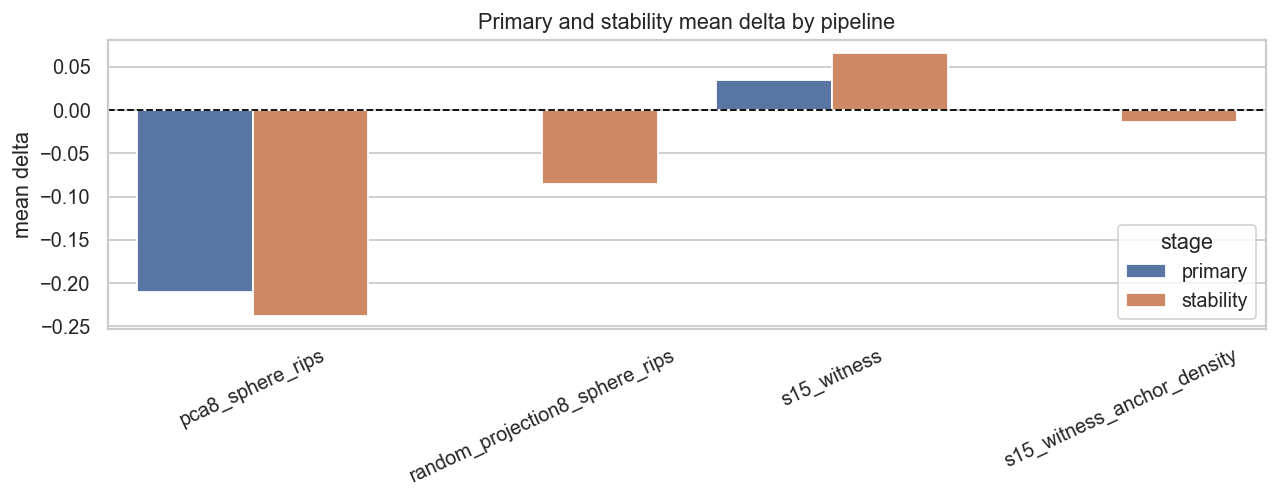

**Stability summary by dataset**

,pipeline,stage,dataset,runs,mean_delta,median_delta,mean_ratio,win_rate,observed_mean,control_mean
0,pca8_sphere_rips,stability,beans,270,-0.2508,-0.2305,0.5488,0.0037,0.2969,0.5476
1,pca8_sphere_rips,stability,cifar10,270,-0.2528,-0.2434,0.0798,0.0000,0.0207,0.2735
2,pca8_sphere_rips,stability,stl10,81,-0.1445,-0.1450,0.1803,0.0247,0.0306,0.1751
3,random_projection8_sphere_rips,stability,beans,30,-0.0743,-0.0770,0.4527,0.0667,0.0602,0.1345
4,random_projection8_sphere_rips,stability,cifar10,30,-0.0940,-0.0918,0.2153,0.0000,0.0240,0.1179
5,random_projection8_sphere_rips,stability,stl10,9,-0.0905,-0.1063,0.3835,0.1111,0.0571,0.1477
6,s15_witness,stability,beans,120,0.0616,0.0220,4.7764,0.5750,0.1774,0.1158
7,s15_witness,stability,cifar10,120,0.0384,0.0285,4.9300,0.5917,0.1806,0.1422
8,s15_witness,stability,stl10,29,0.1984,0.2240,3.2474,0.8621,0.3557,0.1574
9,s15_witness_anchor_density,stability,beans,30,0.0199,-0.0131,1.5247,0.4333,0.1188,0.0988


In [6]:
if pipeline_summary.empty:
    note("Pipeline summary missing", "`pipeline_summary.csv` was not loaded.", "warn")
else:
    display(pipeline_summary.round(4))

    if {"pipeline", "stage", "mean_delta"}.issubset(pipeline_summary.columns):
        fig, ax = plt.subplots(figsize=(10, 4))
        plot = numeric(pipeline_summary.copy(), ["mean_delta", "win_rate"])
        sns.barplot(data=plot, x="pipeline", y="mean_delta", hue="stage", ax=ax)
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title("Primary and stability mean delta by pipeline")
        ax.set_xlabel("")
        ax.set_ylabel("mean delta")
        ax.tick_params(axis="x", rotation=25)
        plt.tight_layout()
        plt.show()

if not stability_summary.empty:
    display(Markdown("**Stability summary by dataset**"))
    display(stability_summary.round(4))

# Appendix B. Topological Readout

,ambient_dim,condition_id,control_kind,dataset,dim,max_persistence,max_persistence_norm,n_features,n_finite,n_points,pipeline,result_id,runtime_seconds,sample_kind,seed,stage,status,threshold_or_filtration,n_witnesses_actual,num_simplices,num_vertices
0,8,005d87f224671ffe,channel_shuffle,cifar10,0,0.352880,0.198693,95,94,95,random_projection8_sphere_rips,005d87f224671ffe__channel_shuffle,2.049087,channel_shuffle,842650268,stability,ok,1.776003,NaN,NaN,NaN
1,8,005d87f224671ffe,channel_shuffle,cifar10,1,0.094121,0.052996,92,92,95,random_projection8_sphere_rips,005d87f224671ffe__channel_shuffle,2.049093,channel_shuffle,842650268,stability,ok,1.776003,NaN,NaN,NaN
2,8,005d87f224671ffe,channel_shuffle,cifar10,2,0.052806,0.029733,66,66,95,random_projection8_sphere_rips,005d87f224671ffe__channel_shuffle,2.049094,channel_shuffle,842650268,stability,ok,1.776003,NaN,NaN,NaN
3,8,005d87f224671ffe,matched_gaussian,cifar10,0,1.659299,0.840110,95,94,95,random_projection8_sphere_rips,005d87f224671ffe__matched_gaussian,0.937850,matched_gaussian,842650268,stability,ok,1.975097,NaN,NaN,NaN
4,8,005d87f224671ffe,matched_gaussian,cifar10,1,0.037071,0.018769,70,70,95,random_projection8_sphere_rips,005d87f224671ffe__matched_gaussian,0.937853,matched_gaussian,842650268,stability,ok,1.975097,NaN,NaN,NaN
5,8,005d87f224671ffe,matched_gaussian,cifar10,2,0.022583,0.011434,40,40,95,random_projection8_sphere_rips,005d87f224671ffe__matched_gaussian,0.937855,matched_gaussian,842650268,stability,ok,1.975097,NaN,NaN,NaN
6,8,005d87f224671ffe,observed,cifar10,0,1.340019,0.670453,95,94,95,random_projection8_sphere_rips,005d87f224671ffe__observed,0.833438,observed,842650268,stability,ok,1.998675,NaN,NaN,NaN
7,8,005d87f224671ffe,observed,cifar10,1,0.029212,0.014616,79,79,95,random_projection8_sphere_rips,005d87f224671ffe__observed,0.833442,observed,842650268,stability,ok,1.998675,NaN,NaN,NaN
8,8,005d87f224671ffe,observed,cifar10,2,0.018842,0.009427,37,37,95,random_projection8_sphere_rips,005d87f224671ffe__observed,0.833444,observed,842650268,stability,ok,1.998675,NaN,NaN,NaN
9,8,005d87f224671ffe,random_tokens,cifar10,0,0.520880,0.262726,95,94,95,random_projection8_sphere_rips,005d87f224671ffe__random_tokens,0.135952,random_tokens,842650268,stability,ok,1.982595,NaN,NaN,NaN


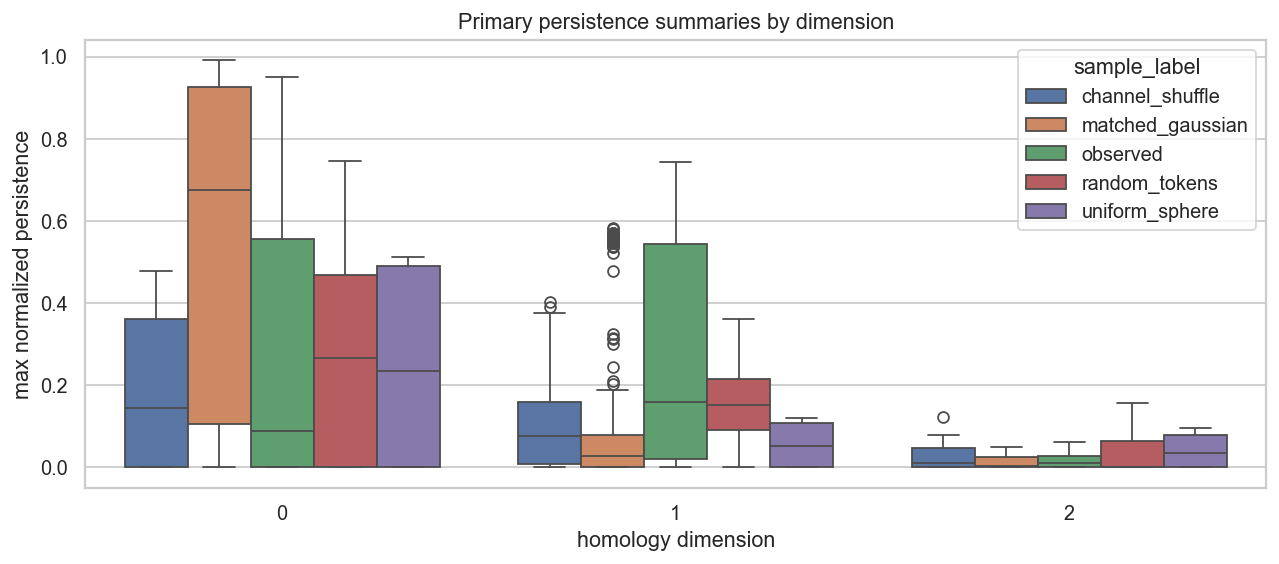

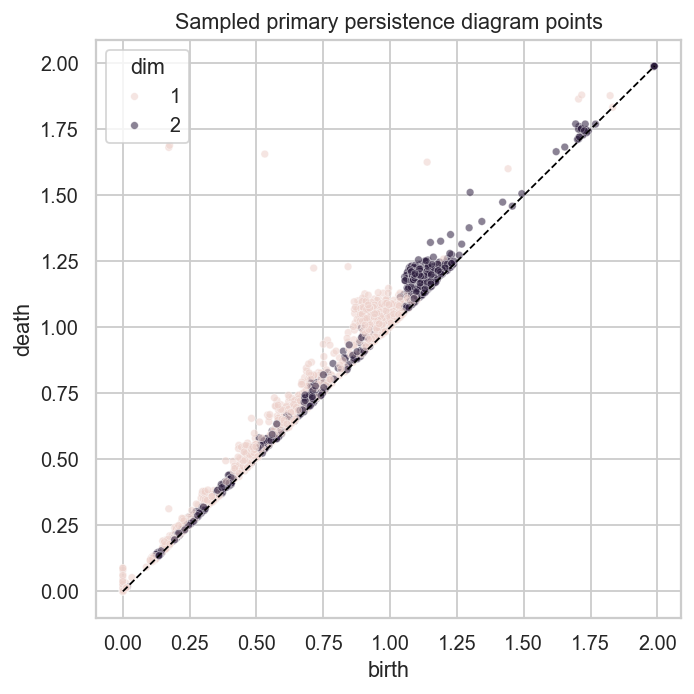

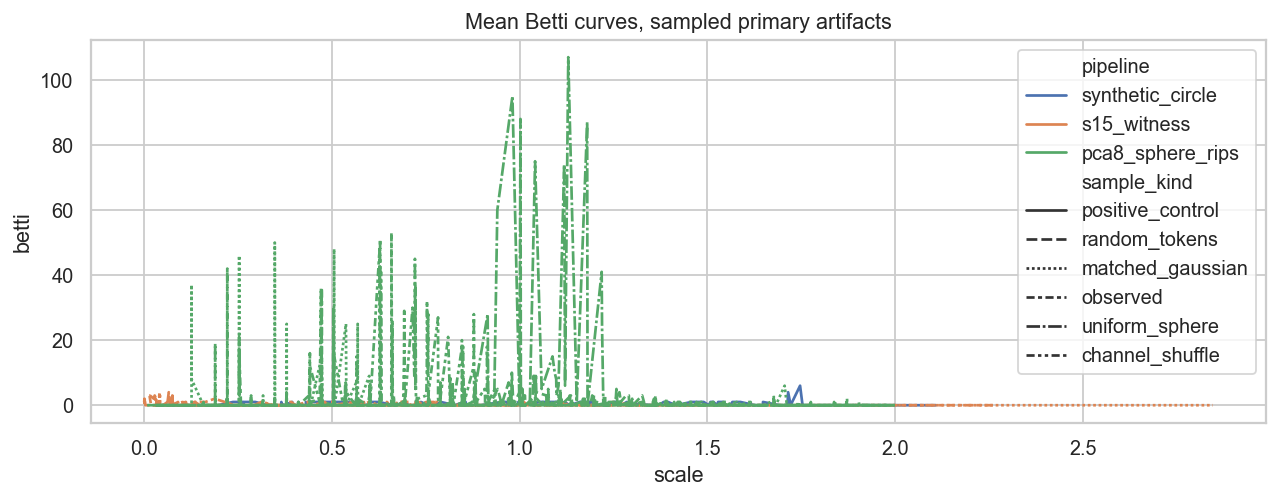

In [7]:
if runs.empty:
    note("Run table missing", "`runs.csv` was not loaded.", "warn")
else:
    run_plot = numeric(runs.copy(), ["dim", "max_persistence_norm", "n_finite"])
    display(run_plot.head(30))

    if {"dim", "max_persistence_norm", "sample_kind", "stage"}.issubset(run_plot.columns):
        compact = run_plot[run_plot["stage"].isin(["primary", "positive_control"])].copy()
        compact["sample_label"] = np.where(
            compact["sample_kind"].astype(str).eq("observed"),
            "observed",
            compact.get("control_kind", pd.Series(["control"] * len(compact))).fillna("control").astype(str),
        )
        fig, ax = plt.subplots(figsize=(10, 4.5))
        sns.boxplot(data=compact, x="dim", y="max_persistence_norm", hue="sample_label", ax=ax)
        ax.set_title("Primary persistence summaries by dimension")
        ax.set_xlabel("homology dimension")
        ax.set_ylabel("max normalized persistence")
        plt.tight_layout()
        plt.show()

def load_optional_topology() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    diagrams = read_csv_artifact("diagrams", OPTIONAL_FILES["diagrams"])
    barcodes = read_csv_artifact("barcodes", OPTIONAL_FILES["barcodes"])
    betti = read_csv_artifact("betti_curves", OPTIONAL_FILES["betti_curves"])
    return diagrams, barcodes, betti


diagrams, barcodes, betti_curves = load_optional_topology()
rendered = False

if not diagrams.empty and {"birth", "death", "dim"}.issubset(diagrams.columns):
    diag = numeric(diagrams, ["birth", "death", "dim"])
    if "stage" in diag.columns:
        diag = diag[diag["stage"].isin(["primary", "positive_control"])]
    diag = diag[diag["dim"].isin([1, 2])]
    if len(diag) > 2000:
        diag = diag.sample(2000, random_state=90501)
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    sns.scatterplot(data=diag, x="birth", y="death", hue="dim", alpha=0.55, s=18, ax=ax)
    finite = diag[["birth", "death"]].replace([np.inf, -np.inf], np.nan).dropna()
    if not finite.empty:
        lo = float(finite.min().min())
        hi = float(finite.max().max())
        ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1)
    ax.set_title("Sampled primary persistence diagram points")
    plt.tight_layout()
    plt.show()
    rendered = True

if not betti_curves.empty:
    curve = numeric(betti_curves, ["filtration", "epsilon", "scale", "betti", "dim"])
    if "stage" in curve.columns:
        curve = curve[curve["stage"].isin(["primary", "positive_control"])]
    x_col = next((col for col in ["filtration", "epsilon", "scale"] if col in curve.columns), None)
    if x_col and {"betti", "dim", "pipeline", "sample_kind"}.issubset(curve.columns):
        curve = (
            curve.groupby(["pipeline", "sample_kind", "dim", x_col], as_index=False)["betti"]
            .mean()
            .query("dim in [1, 2]")
        )
        if len(curve) > 3500:
            curve = curve.sample(3500, random_state=90501)
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.lineplot(data=curve, x=x_col, y="betti", hue="pipeline", style="sample_kind", ax=ax)
        ax.set_title("Mean Betti curves, sampled primary artifacts")
        plt.tight_layout()
        plt.show()
        rendered = True

if not rendered:
    note("Optional topology artifacts not rendered", "The scalar run summaries above are available; diagram/Betti files were missing or schema-incompatible.", "info")

# Appendix C. Reproducibility Audit

In [8]:
inventory = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": display_path(path) if path.exists() else str(path),
            "required": name in REQUIRED_FILES,
            "exists": path.exists(),
            "bytes": path.stat().st_size if path.exists() else 0,
            "load_error": load_errors.get(name, ""),
        }
        for name, path in {**REQUIRED_FILES, **OPTIONAL_FILES}.items()
    ]
)

if manifest:
    manifest_display = []
    for key, value in manifest.items():
        if isinstance(value, (dict, list)):
            value = json.dumps(value, indent=2, sort_keys=True)
        manifest_display.append({"field": key, "value": value})
    display(Markdown("**Manifest**"))
    display(pd.DataFrame(manifest_display))
else:
    display(
        pd.DataFrame(
            [
                {"field": "notebook_python", "value": platform.python_version()},
                {"field": "notebook_platform", "value": platform.platform()},
                {"field": "output_dir", "value": str(OUT_DIR)},
            ]
        )
    )

if failed_runs.empty:
    note("No failed runs", "`failed_runs.csv` is absent or empty.", "ok")
else:
    display(Markdown("**Failed runs**"))
    display(failed_runs.head(100))

display(Markdown("**Artifact inventory**"))
display(inventory)

if not conditions.empty:
    coverage = (
        conditions.groupby(["dataset", "stage"], dropna=False)
        .size()
        .reset_index(name="planned_conditions")
    )
    display(Markdown("**Condition coverage plan**"))
    display(coverage)

**Manifest**

,field,value
0,command,/pkg/modal/_container_entrypoint.py
1,conditions,10320
2,config_hash,c8fa8541f1bf01fefb5e112c7cd43b1ceb8af043b8f3cf7095a7de160ba787e2
3,created_at,2026-05-01T13:32:06.134777+00:00
4,datasets,"[\n ""beans"",\n ""cifar10"",\n ""fashion_mnist"",\n ""stl10""\n]"
5,git_commit,unknown
6,output_dir,/root/outputs/confirmatory_h1_v1
7,platform,Linux-4.4.0-x86_64-with-glibc2.36
8,python,3.12.10
9,smoke,False


> **OK: No failed runs**
>
> `failed_runs.csv` is absent or empty.

**Artifact inventory**

,artifact,path,required,exists,bytes,load_error
0,manifest,outputs/confirmatory_h1_v1_partial_modal/manifest.json,True,True,681,
1,conditions,outputs/confirmatory_h1_v1_partial_modal/conditions.csv,True,True,2168560,
2,runs,outputs/confirmatory_h1_v1_partial_modal/runs.csv,True,True,4125306,
3,paired_primary,outputs/confirmatory_h1_v1_partial_modal/paired_primary.csv,True,True,69395,
4,verdict,outputs/confirmatory_h1_v1_partial_modal/verdict.json,True,True,1438,
5,pipeline_summary,outputs/confirmatory_h1_v1_partial_modal/pipeline_summary.csv,True,True,988,
6,dataset_summary,outputs/confirmatory_h1_v1_partial_modal/dataset_summary.csv,True,True,3100,
7,stability_summary,outputs/confirmatory_h1_v1_partial_modal/stability_summary.csv,True,True,1979,
8,failed_runs,outputs/confirmatory_h1_v1_partial_modal/failed_runs.csv,False,True,1,
9,diagrams,outputs/confirmatory_h1_v1_partial_modal/diagrams.csv,False,True,197602528,


**Condition coverage plan**

,dataset,stage,planned_conditions
0,beans,positive_control,30
1,beans,primary,300
2,beans,stability,2250
3,cifar10,positive_control,30
4,cifar10,primary,300
5,cifar10,stability,2250
6,fashion_mnist,positive_control,30
7,fashion_mnist,primary,300
8,fashion_mnist,stability,2250
9,stl10,positive_control,30
